In [2]:
import pandas as pd
import numpy as np

ratings = pd.read_csv(
    "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

print(ratings.head())
print(ratings.shape)

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
(100000, 4)


In [3]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    ratings,
    test_size=0.2, #Im gonna split 20% for test
    random_state=42
)

print(train.shape)
print(test.shape)

(80000, 4)
(20000, 4)


# Memory Based CF

User-item matrix

In [4]:
R = train.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print(R.shape)
print(R.head())

(943, 1653)
movie_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                               ...   
1          NaN   3.0   4.0   NaN   3.0   NaN   4.0   NaN   5.0   3.0  ...   
2          4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
3          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
5          4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

movie_id  1668  1670  1671  1672  1673  1676  1678  1679  1680  1681  
user_id                                                               
1          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
3          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
4          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
5          NaN   NaN  

The dataset is very sparse, i.e. it has lot of NaN values and we're taking user similarity where both users have rated that movie

In [5]:
#use nested for loop to filter out ratings which both users have given
from sklearn.metrics.pairwise import cosine_similarity

R_filled = R.fillna(0)

similarity = cosine_similarity(R_filled)

similarity = pd.DataFrame(
    similarity,
    index=R.index,
    columns=R.index
 )

print(similarity.head()) #gives sim(i, j)

user_id       1         2         3         4         5         6         7    \
user_id                                                                         
1        1.000000  0.136196  0.030424  0.026203  0.284613  0.331412  0.319056   
2        0.136196  1.000000  0.114644  0.168220  0.093128  0.162165  0.095848   
3        0.030424  0.114644  1.000000  0.346894  0.000000  0.085071  0.032829   
4        0.026203  0.168220  0.346894  1.000000  0.011848  0.051287  0.075209   
5        0.284613  0.093128  0.000000  0.011848  1.000000  0.168527  0.298438   

user_id       8         9         10   ...       934       935       936  \
user_id                                ...                                 
1        0.274139  0.083486  0.281396  ...  0.277459  0.084849  0.205849   
2        0.091360  0.149476  0.125701  ...  0.149359  0.268977  0.320095   
3        0.053875  0.060177  0.052552  ...  0.021713  0.017707  0.154299   
4        0.142100  0.060465  0.035202  ...  0.034908

We will be using KNN to predict output as rating by user depends on similarity of K Nearest Similar Neighbours

In [6]:
def predict(user, movie, K=20): #picking top k similar users
    if movie not in R.columns:
        return train["rating"].mean()
    
    sims = similarity.loc[user].drop(user)

    sims = sims[sims>0]

    sims = sims[R.loc[sims.index, movie].notna()]
    sims = sims.sort_values(ascending=False).head(K)

    if (len(sims) == 0):
        return train["rating"].mean()

    ratings = R.loc[sims.index, movie] #neighbor ratings

    return np.clip(
        np.sum(sims.values * ratings.values) / np.sum(sims.values),
        1 , 5 
    ) #np.clip() forces predictions to stay between 1 and 5

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for K in [5, 10, 20, 50]:

    predictions = [
        predict(row["user_id"], row["movie_id"], K)
        for _, row in test.iterrows()
    ]

    mae = mean_absolute_error(test["rating"], predictions)
    rmse = np.sqrt(mean_squared_error(test["rating"], predictions))

    results.append([K, mae, rmse])

results

[[5, 0.8420341264596369, np.float64(1.061974765932667)],
 [10, 0.8151493886313372, np.float64(1.0261999232718149)],
 [20, 0.8028164351910148, np.float64(1.011828294689408)],
 [50, 0.8010231653254491, np.float64(1.0098399681374197)]]

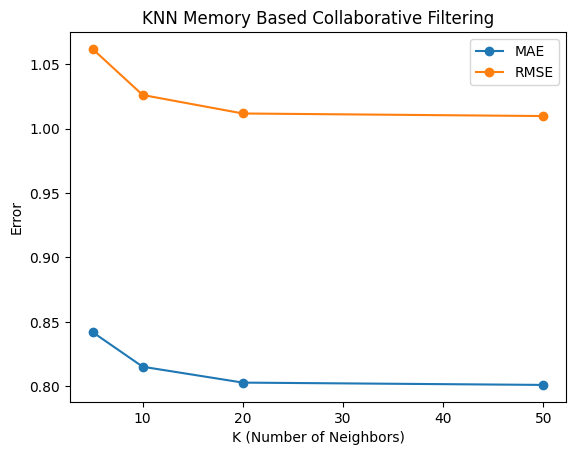

In [8]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(
    results,
    columns=["K", "MAE", "RMSE"]
)

plt.plot(results_df["K"], results_df["MAE"], marker='o', label="MAE")
plt.plot(results_df["K"], results_df["RMSE"], marker='o', label="RMSE")

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Error")
plt.title("KNN Memory Based Collaborative Filtering")
plt.legend()
plt.show()

The error converges to lower value for higher values of K

# Model Based CF
Matrix Factorisation

In [ ]:
users = train["user_id"].unique()
movies = train["movie_id"].unique()

user_to_idx = {u : i for i, u in enumerate(users)}
movie_to_idx = {m : i for i, m in enumerate(movies)}
#convert to indices to access in matrix             

In Model Based CF we represent users and movies in terms of latent vectors based on k hidden features 

In [17]:
k = 50 #no. of features

P = np.random.normal(0, 0.1, (len(users), k))
Q = np.random.normal(0, 0.1, (len(movies), k))
#we initialise random values in order to perform gradient descent 

lr = 0.005
reg = 0.02
epochs = 20

#Training Loop
for epoch in range(epochs):
    for _, row in train.iterrows():
        u = user_to_idx[row["user_id"]]
        i = movie_to_idx[row["movie_id"]]
        r = row["rating"]


KeyError: np.int64(1411)